In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


In [9]:
path_input = '../data/'
path_output = '../figures/'

In [10]:

ds_AMEDA = xr.open_dataset(path_input + 'DYNED_GS2_SWOT_on_DUACS.nc') 
ds_AMEDA_full = xr.open_dataset(path_input + 'eddy_atlas_1_8.nc') 


ds_DUACS_full_sel = xr.open_dataset(path_input + 'field_full_duacs.nc')
ds_DUACS_crop_sel = xr.open_dataset(path_input + 'field_crops_duacs.nc')


LON2D, LAT2D = np.meshgrid(ds_DUACS_crop_sel.longitude.values, ds_DUACS_crop_sel.latitude.values)
date = np.datetime64('2024-05-03')

id_eddies_full = np.where(ds_AMEDA_full.time.values == date)[0]


In [11]:
theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

x_circle_small = np.cos(theta)/2.5
y_circle_small = np.sin(theta)/2.5


arrow_length = 0.8  # Adjust length as needed
x_start = 0
y_start = 0
theta_rot = 0
x_end = x_start + arrow_length * np.cos(theta_rot*(+1))
y_end = y_start + arrow_length * np.sin(theta_rot*(+1))

props1 = dict(boxstyle='round', facecolor='w', alpha=1)
n_quiver = 15


def plot_composite(ax, compo_2D, vmin, vmax, cmap0):
    p1 = ax.pcolormesh(compo_2D.x, compo_2D.y,  compo_2D, vmin = vmin, vmax = vmax, cmap = cmap0)
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 3)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = 1, linestyle = '--')
    ax.set_xticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'], rotation = 90)
    ax.set_yticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'])
    ax.plot(x_circle_small, y_circle_small, color = 'k', linewidth = 3)
    ax.plot(x_circle_small, y_circle_small, color = 'w', linewidth = 1)
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 3)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = 1, linestyle = '--')

    return p1

In [12]:
###########
# --- Get eddies close to the SWOT track
###########


mask_swot = np.ma.masked_where(np.isnan(ds_DUACS_crop_sel.ssha.values), ds_DUACS_crop_sel.ssha.values)
mask_lon = np.ma.masked_where(np.isnan(ds_DUACS_crop_sel.ssha.values), LON2D)
mask_lat = np.ma.masked_where(np.isnan(ds_DUACS_crop_sel.ssha.values), LAT2D)

mask_swot = np.ma.masked_where(np.isnan(ds_DUACS_crop_sel.ssha.values), ds_DUACS_crop_sel.ssha.values)

index_in_swot_90 = []
index_in_swot_50 = []
index_in_swot_05 = []

for i in id_eddies_full:

    lon_contour = ds_AMEDA_full.x_max[i, :].values
    lat_contour = ds_AMEDA_full.y_max[i, :].values

    # Skip NaNs in the contour
    valid_points = ~np.isnan(lon_contour) & ~np.isnan(lat_contour)
    lon_contour = lon_contour[valid_points]
    lat_contour = lat_contour[valid_points]

    # Convert lat/lon to nearest indices in the mask
    lat_idx = np.searchsorted(ds_DUACS_crop_sel.latitude.values, lat_contour)
    lon_idx = np.searchsorted(ds_DUACS_crop_sel.longitude.values, lon_contour)

    # Make sure indices are within bounds
    lat_idx = np.clip(lat_idx, 0, mask_swot.shape[0]-1)
    lon_idx = np.clip(lon_idx, 0, mask_swot.shape[1]-1)

    # Check if any point in this contour is masked
    if mask_swot[lat_idx, lon_idx].count()/len(mask_swot[lat_idx, lon_idx])==1: # take eddies that falls in the mask 
        index_in_swot_90.append(i)
    
    if mask_swot[lat_idx, lon_idx].count()/len(mask_swot[lat_idx, lon_idx])>.5: # take eddies that falls in the mask 
        index_in_swot_50.append(i)

    if mask_swot[lat_idx, lon_idx].count()/len(mask_swot[lat_idx, lon_idx])>.05: # take eddies that falls in the mask 
        index_in_swot_05.append(i)
        
# # Get indices of valid (non-masked) points
valid_idx = np.where(~mask_swot.mask)  # returns tuple of arrays (lat_idx, lon_idx)

# # Get corresponding latitudes and longitudes
lats = ds_DUACS_crop_sel.latitude.values[valid_idx[0]]
lons = ds_DUACS_crop_sel.longitude.values[valid_idx[1]]



<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48085/493735124.py:27: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude [$^{\circ}$E]')
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48085/493735124.py:28: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude [$^{\circ}$N]')
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48085/493735124.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(path_output + 'FigS3.png', dpi = 300, bbox_inches = 'tight')
/Users/gwen29360/opt/anaconda3/envs/swot/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(byte

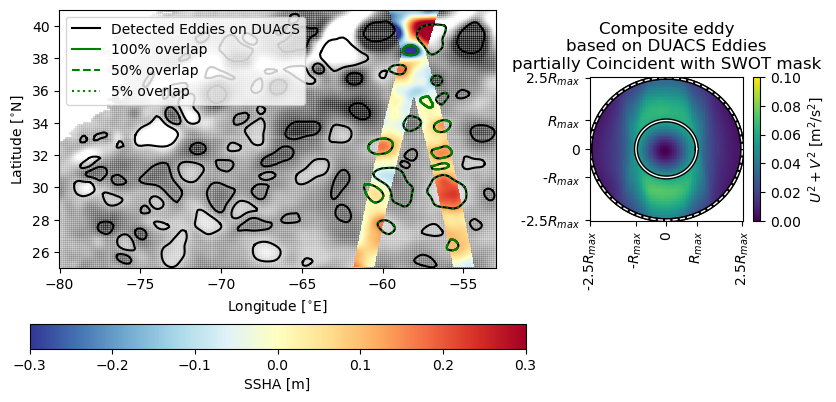

In [14]:
fig, ax = plt.subplots()
ax.pcolor(ds_DUACS_full_sel.longitude, ds_DUACS_full_sel.latitude, ds_DUACS_full_sel.sla[:,:], vmin = -.3, vmax = .3, cmap = 'binary_r', alpha = .5)


for id_eddy in id_eddies_full:
    ax.plot(ds_AMEDA_full.x_max[id_eddy,:], ds_AMEDA_full.y_max[id_eddy,:], color = 'k')
ax.plot(ds_AMEDA_full.x_max[id_eddy,:], ds_AMEDA_full.y_max[id_eddy,:], color = 'k', label = 'Detected Eddies on DUACS')

for id_eddy_poly in index_in_swot_90:
    ax.plot(ds_AMEDA_full.x_max[id_eddy_poly,:], ds_AMEDA_full.y_max[id_eddy_poly,:], color = 'green')

ax.plot(ds_AMEDA_full.x_max[id_eddy_poly,:], ds_AMEDA_full.y_max[id_eddy_poly,:], color = 'green', label = '100% overlap')

for id_eddy_poly in index_in_swot_50:
    ax.plot(ds_AMEDA_full.x_max[id_eddy_poly,:], ds_AMEDA_full.y_max[id_eddy_poly,:], linestyle = '--', color = 'green')
ax.plot(ds_AMEDA_full.x_max[id_eddy_poly,:], ds_AMEDA_full.y_max[id_eddy_poly,:], color = 'green', linestyle = '--', label = '50% overlap')

for id_eddy_poly in index_in_swot_05:
    ax.plot(ds_AMEDA_full.x_max[id_eddy_poly,:], ds_AMEDA_full.y_max[id_eddy_poly,:], linestyle = ':', color = 'green')


ax.plot(ds_AMEDA_full.x_max[id_eddy_poly,:], ds_AMEDA_full.y_max[id_eddy_poly,:], color = 'green', linestyle = ':', label = '5% overlap')



p1 = ax.pcolormesh(ds_DUACS_crop_sel.longitude, ds_DUACS_crop_sel.latitude, ds_DUACS_crop_sel.ssha, vmin = -.3, vmax = .3, cmap = 'RdYlBu_r')
ax.set_xlabel('Longitude [$^{\circ}$E]')
ax.set_ylabel('Latitude [$^{\circ}$N]')


plt.colorbar(p1, label = 'SSHA [m]', orientation = 'horizontal')
ax.set_aspect('equal', 'box')
ax.legend()

ax_inset = fig.add_axes([1, .44, .3, .3])

vmin = 0
vmax = .1
ds_to_save_swot = xr.open_dataset('/Users/gwen29360/Desktop/POSTDOC/LEGOS/SWOT/AMEDA/composites/composite_DUACS_GS2_cyclonic_bad_mask.nc')
data = ds_to_save_swot.composite[1, :, :]**2 + ds_to_save_swot.composite[2, :, :]**2
p1 = plot_composite(ax_inset, data, vmin, vmax, 'viridis')
ax.set_aspect('equal', 'box')
plt.colorbar(p1, label = '$U^{2} + V^{2}$ [m$^2$/s$^2$]')
ax_inset.set_title('Composite eddy\nbased on DUACS Eddies\npartially Coincident with SWOT mask')


plt.savefig(path_output + 'FigS3.png', dpi = 300, bbox_inches = 'tight')